# Overlap Inspection for Whole-Slide Inference Outputs

This notebook loads a given slide image and its corresponding inference txt, computes duplicate detections based on IoU thresholds, and visualizes overlapping pairs/clusters.

Instructions:
- Set the paths below to your image and label txt.
- Adjust `IOU_THRESH` if needed.
- Run all cells to generate visualization and summary stats.



Detections: 1080
Clusters (size>1): 68
Top clusters (indices): [[683, 765, 766, 767], [34, 35, 36], [49, 50, 51], [271, 335, 337], [359, 360, 432]]


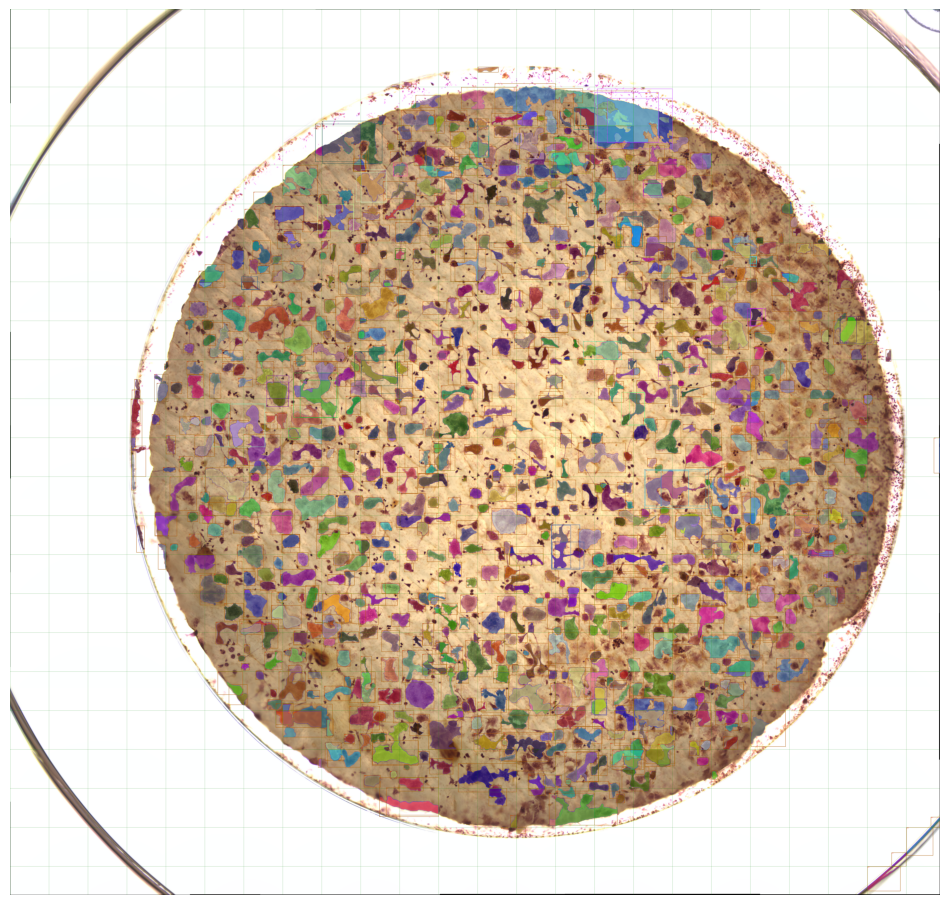

{'total_detections': 1080, 'num_clusters_gt1': 68, 'estimated_duplicate_instances': 78, 'iou_threshold': 0.5}


In [2]:
import os
import csv
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# ---- User inputs ----
IMG_PATH = r"output_noise_m_h1\OCL_Bones_Chips_Roux_transfer_2_File_1cfba8c1_3d61_4526_8f5a_3693e3a7951d.tif"  # change if needed
TXT_PATH = r"output_noise_m_h1\OCL_Bones_Chips_Roux_transfer_2_File_1cfba8c1_3d61_4526_8f5a_3693e3a7951d.txt"  # change if needed
IOU_THRESH = 0.5  # overlap threshold to consider duplicates
MAX_PAIRS_TO_SHOW = 50

assert os.path.exists(IMG_PATH), f"Image not found: {IMG_PATH}"
assert os.path.exists(TXT_PATH), f"Label txt not found: {TXT_PATH}"

# ---- Utils ----
def parse_inference_txt(txt_path: str):
    boxes = []  # [x1,y1,x2,y2,score]
    masks = []  # list of arrays of shape (K,2)
    with open(txt_path, 'r') as f:
        reader = csv.reader(f)
        header = next(reader, None)
        for row in reader:
            if len(row) == 0:
                continue
            # row: [box_x1,box_y1,box_x2,box_y2,objectness_score,mask_x1,mask_y1,mask_x2,mask_y2,...]
            vals = [float(x) for x in row if len(x) > 0]
            if len(vals) < 5:
                continue
            x1, y1, x2, y2, score = vals[:5]
            boxes.append([x1, y1, x2, y2, score])
            if len(vals) > 5:
                ms = np.array(vals[5:], dtype=float)
                if ms.size % 2 == 0 and ms.size >= 6:
                    masks.append(ms.reshape(-1, 2))
                else:
                    masks.append(None)
            else:
                masks.append(None)
    return np.array(boxes, dtype=float), masks


def box_iou_matrix(boxes_xyxy: np.ndarray) -> np.ndarray:
    # boxes_xyxy: Nx4
    if boxes_xyxy.size == 0:
        return np.zeros((0, 0), dtype=float)
    boxes = boxes_xyxy
    area = (boxes[:, 2] - boxes[:, 0]).clip(min=0) * (boxes[:, 3] - boxes[:, 1]).clip(min=0)
    inter = np.zeros((len(boxes), len(boxes)), dtype=float)
    for i in range(len(boxes)):
        xx1 = np.maximum(boxes[i, 0], boxes[:, 0])
        yy1 = np.maximum(boxes[i, 1], boxes[:, 1])
        xx2 = np.minimum(boxes[i, 2], boxes[:, 2])
        yy2 = np.minimum(boxes[i, 3], boxes[:, 3])
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter[i, :] = w * h
    union = area.reshape(-1, 1) + area.reshape(1, -1) - inter
    with np.errstate(divide='ignore', invalid='ignore'):
        iou = np.where(union > 0, inter / union, 0.0)
    np.fill_diagonal(iou, 0.0)
    return iou


def build_iou_graph(iou: np.ndarray, thr: float):
    n = iou.shape[0]
    edges = {}
    for i in range(n):
        edges[i] = []
        for j in range(n):
            if i != j and iou[i, j] >= thr:
                edges[i].append(j)
    return edges


def connected_components(edges):
    visited = set()
    comps = []
    for start in edges:
        if start in visited:
            continue
        stack = [start]
        comp = []
        visited.add(start)
        while stack:
            u = stack.pop()
            comp.append(u)
            for v in edges[u]:
                if v not in visited:
                    visited.add(v)
                    stack.append(v)
        comps.append(sorted(comp))
    return comps

# ---- Load data ----
boxes, masks = parse_inference_txt(TXT_PATH)
boxes_xyxy = boxes[:, :4] if boxes.size else np.zeros((0, 4))
scores = boxes[:, 4] if boxes.size else np.zeros((0,))

print(f"Detections: {len(boxes_xyxy)}")

# ---- IoU graph and clusters ----
iou = box_iou_matrix(boxes_xyxy)
edges = build_iou_graph(iou, IOU_THRESH)
clusters = [c for c in connected_components(edges) if len(c) > 1]
clusters_sorted = sorted(clusters, key=lambda c: -len(c))

print(f"Clusters (size>1): {len(clusters_sorted)}")
if clusters_sorted:
    print("Top clusters (indices):", clusters_sorted[:5])

# ---- Visualization ----
img = Image.open(IMG_PATH).convert('RGB')
draw = ImageDraw.Draw(img, 'RGBA')

# draw all boxes faintly
for b in boxes_xyxy:
    x1, y1, x2, y2 = b
    draw.rectangle([(x1, y1), (x2, y2)], outline=(0,255,0,128), width=2)

# highlight duplicate clusters
cluster_colors = []
np.random.seed(0)
for _ in clusters_sorted:
    cluster_colors.append(tuple(np.random.randint(0, 255, 3).tolist()))

pairs_shown = 0
for ci, comp in enumerate(clusters_sorted):
    color = cluster_colors[ci % len(cluster_colors)] if cluster_colors else (255,0,0)
    for idx in comp:
        x1, y1, x2, y2 = boxes_xyxy[idx]
        draw.rectangle([(x1, y1), (x2, y2)], outline=color+(255,), width=3)
    pairs_shown += len(comp) - 1
    if pairs_shown >= MAX_PAIRS_TO_SHOW:
        break

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

# ---- Summary ----
num_duplicates = sum(len(c) - 1 for c in clusters_sorted)
print({
    'total_detections': int(len(boxes_xyxy)),
    'num_clusters_gt1': int(len(clusters_sorted)),
    'estimated_duplicate_instances': int(num_duplicates),
    'iou_threshold': IOU_THRESH,
})

